### Tauha Imran 22i1239 - G4
#### NLP - A2 - Vectors & Language Modelling
---

### 1. OCR and Preprocessing
```

Extracting text from PDF judgements using:

● pdf2image → to convert PDF pages to images

● pytesseract or EasyOCR → to extract text from images


Clean and normalize the text: remove headers, footers, and line breaks; fix
hyphenation and punctuation; split into sentences.
Save each record in JSON format:
```
{
"case_id": "SCP_2025_001",
"pdf_source": "path/to/file.pdf",
"ocr_text": "Full extracted text..."
}

In [ ]:
# install pre req libraries
%pip install pdf2image pytesseract pillow nltk
%pip install pdf2image pytesseract easyocr nltk spacy
%pip install scikit-learn



In [15]:
#including libraries and downloading necessary data

import os, json, re
import numpy as np
from pdf2image import convert_from_path #using this to pfd -> image conversion
import pytesseract # THE OCR TOOL OF MY CHOICE
import nltk, spacy
from nltk.tokenize import sent_tokenize, word_tokenize #tokenizer functions
nltk.download('punkt')

#PS - i installed tesseract-ocr in my system using https://github.com/UB-Mannheim/tesseract/wiki
#and added the path to system environment variables C:\Program Files\Tesseract-OCR
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
#  the line above kinda did the environment variable setting lol..

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [16]:
# Ensure required NLTK tokenizer resources are available in a local nltk_data directory
import nltk, os
nltk_data_dir = os.path.join(os.getcwd(), 'nltk_data')
os.makedirs(nltk_data_dir, exist_ok=True)
# Add our local nltk_data directory to nltk lookup paths if not already present
if nltk_data_dir not in nltk.data.path:
    nltk.data.path.append(nltk_data_dir)
# Some environments require both 'punkt' and 'punkt_tab' tokenizers (punkt_tab contains language-specific tables)
required = {'punkt':'tokenizers/punkt', 'punkt_tab':'tokenizers/punkt_tab'}
for pkg, path in required.items():
    try:
        nltk.data.find(path)
        print(f"NLTK resource '{pkg}' already present ({path})")
    except LookupError:
        print(f"Downloading NLTK resource: {pkg} to {nltk_data_dir}...")
        nltk.download(pkg, download_dir=nltk_data_dir)
print('NLTK data path:', nltk_data_dir)
print('nltk.data.path:', nltk.data.path)

NLTK resource 'punkt' already present (tokenizers/punkt)
NLTK resource 'punkt_tab' already present (tokenizers/punkt_tab)
NLTK data path: f:\Projects\NLPlayground\Assignment2_Vectors & Language Modeling\nltk_data
nltk.data.path: ['C:\\Users\\LENOVO/nltk_data', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data', 'C:\\Users\\LENOVO\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data', 'f:\\Projects\\NLPlayground\\Assignment2_Vectors & Language Modeling\\nltk_data']


In [17]:
from pdf2image import convert_from_path
import pytesseract
import json
import re

# function to convert pdf to text using OCR
def pdf_to_text(pdf_path):
    pages = convert_from_path(pdf_path, dpi=300) # <<---- this converts each page to an image
    text = ""
    for page in pages:
        text += pytesseract.image_to_string(page)
    return text

def clean_text(text):
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'-\s+', '', text)  # fix hyphenation
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()

pdf_path = "data/sample_case.pdf"
raw_text = pdf_to_text(pdf_path)
cleaned_text = clean_text(raw_text)

record = {
    "case_id": "SCP_2025_001",
    "pdf_source": pdf_path,
    "ocr_text": cleaned_text
}

with open("outputs/ocr_data.json", "w", encoding="utf-8") as f:
    json.dump(record, f, indent=4)

#print some stats
print(f"Extracted {len(cleaned_text)} characters from the PDF.")

Extracted 7601 characters from the PDF.


In [18]:
#print some stats
print(f"Extracted {len(cleaned_text)} characters from the PDF.")

Extracted 7601 characters from the PDF.


---

### 2. Neural Language Model for Sentence Embeddings

Now we build a Neural Language Model (from scratch) to learn distributed vector representations (embeddings) of sentences.

1. Data Preparation
Use your provided legal text corpus.
Example:

The court found the defendant guilty.
The defendant appealed the decision.
The judge dismissed the case.

1. Tokenize text into words.
2. Build a vocabulary of unique words.
3. Create training samples depending on your chosen model:
o CBOW: Predict a word from the surrounding context.
o Skip-gram: Predict surrounding context words from a given target
word.

2. Model Implementation (Using NumPy Only)

A minimal architecture:
Input → Hidden Layer (Word Embeddings) → Output (Softmax)

Example initialisation:
vocab_size = len(vocab)
embedding_dim = 50
W1 = np.random.randn(vocab_size, embedding_dim)
W2 = np.random.randn(embedding_dim, vocab_size)
Train using cross-entropy loss and gradient descent to predict target
words.

In [19]:
import json
import re
import nltk # natural language toolkit
from nltk.tokenize import sent_tokenize, word_tokenize  #functions that i'mma use for tokenization
nltk.download('punkt')  # downloading the punkt tokenizer models

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
# STEP1 -> Loading the ocr data
# now getting the data from the .json file and loading it into memory for our nueral network model.

#LOAD THE OCR DATA FROM JSON
with open("outputs/ocr_data.json", "r", encoding="utf-8") as f:
    record = json.load(f)

text = record["ocr_text"].lower() #making it all lowercase

#splitting it into sentences.
sentences = sent_tokenize(text)
print(f"Total sentences extracted: {len(sentences)}")


Total sentences extracted: 33


In [21]:
# STEP2 -> Tokenie & Build Vocabulary

#tokenizing all the words
tokens = word_tokenize(text)
print(f"Total tokens extracted: {len(tokens)}")

#removing punctuation and non-alphabetic tokens
tokens = [token for token in tokens if token.isalpha()]
print(f"Total alphabetic tokens after cleaning: {len(tokens)}")


#building vocabulary
vocab = sorted(set(tokens))
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx:word for word,idx in word2idx.items()}

print(f"Vocabulary size: {len(vocab)}") #printing vocab size

Total tokens extracted: 1377
Total alphabetic tokens after cleaning: 1151
Vocabulary size: 360


In [22]:
#  STEP 3 - Generate Training Data ( Skip-gram pairs)
import random

def generate_skipgram_pairs(tokens, window_size=2):
    pairs = []
    for i, target_word in enumerate(tokens):
        context_indices = list(range(max(0, i - window_size), min(len(tokens), i + window_size + 1)))
        context_indices.remove(i)  # remove the target word index
        for j in context_indices:
            context_word = tokens[j]
            pairs.append((target_word, context_word))
    return pairs

pairs = generate_skipgram_pairs(tokens, window_size=2)
print(f"Total skip-gram pairs generated: {len(pairs)}")

#to verify
#random.sample(pairs, 5)


Total skip-gram pairs generated: 4598


In [23]:
# STEP4 -> Initializing the nueral network model using Numpy only
import numpy as np

v = len(vocab)  #vocab size
embedding_dim = 100  #dimension of the embedding vector

# randomly initializing weight matrices
W1 = np.random.rand(v, embedding_dim)  #input to hidden
W2 = np.random.rand(embedding_dim, v)  #hidden to output

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

In [24]:
# STEP 5 -> the training loop

def one_hot_encode(word, word2idx, vocab_size):
    vec = np.zeros(vocab_size)
    vec[word2idx[word]] = 1
    return vec

def train_skipgram(pairs, epochs = 5 , learning_rate = 0.05):
    global W1, W2
    v = len(vocab) #vocab size
    for epoch in range(epochs):
        loss = 0
        for target_word, context_word in random.sample(pairs, 500): # using a subset of 500 for faster training
            target_idx = word2idx[target_word]
            context_idx = word2idx[context_word]
            
            x = one_hot_encode(target_word, word2idx, v)

            #forward pass
            h = np.dot(W1.T, x)  #hidden layer
            u = np.dot(W2.T, h)  #output layer 
            y_pred = softmax(u)  #predicted output

            #compute loss (cross-entropy)
            loss += -np.log(y_pred[context_idx] + 1e-9)

            #backpropagation / backward pass / weight updates
            e = y_pred
            e[context_idx] -= 1
            dW2 = np.outer(h, e)
            dW1 = np.outer(x, np.dot(W2, e))
            
            # update weights
            W1 -= learning_rate * dW1
            W2 -= learning_rate * dW2

        # print average loss per epoch
        print(f"Epoch {epoch+1}, Loss: {loss/500:.4f}")


############################################
# Training the model
train_skipgram(pairs, epochs=5, learning_rate=0.05)



Epoch 1, Loss: 5.9152
Epoch 2, Loss: 5.5082
Epoch 2, Loss: 5.5082
Epoch 3, Loss: 5.3968
Epoch 3, Loss: 5.3968
Epoch 4, Loss: 5.3808
Epoch 4, Loss: 5.3808
Epoch 5, Loss: 5.3193
Epoch 5, Loss: 5.3193


In [25]:
# STEP 6 -> Generating Sentence Embeddings
def get_sentence_embedding(sentence):
    words = [w for w in word_tokenize(sentence.lower()) if w in word2idx]
    if not words:
        return np.zeros(embedding_dim)
    vectors = [W1[word2idx[w]] for w in words]
    return np.mean(vectors, axis=0)

sentence_vectors = [get_sentence_embedding(s) for s in sentences]
print(f"Computed {len(sentence_vectors)} sentence embeddings.")


Computed 33 sentence embeddings.


---

### 3. Extractive Summarization

Once sentence embeddings are computed:
1. Compute a document-level embedding as the mean of all sentence vectors.
2. Measure sentence importance using cosine similarity between each sentence
vector and the document vector.
3. Rank sentences by importance score.
4. Select top-k sentences for the summary.
Each training sample should contain:

```
{
"input": "Full OCR text",
"target": "Summarised text"
}
```

Output Example.

```
Original:
The court found the defendant guilty. The defendant appealed the decision. The judge
dismissed the case due to insufficient evidence.

Extractive Summary (Top 2 Sentences):
The court found the defendant guilty. The judge dismissed the case due to insufficient
evidence.
```

In [26]:
# Here's the code for the extractive summarization using cosine similarity
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity  # just the cosine similarity function

def extractive_summary(sentences, sentence_vectors, top_k=5):
    # ensure we have a numpy array for math operations
    sentence_vectors = np.array(sentence_vectors)
    # 1 - computing the document-level embedding via the mean of all sentence embeddings
    doc_embedding = np.mean(sentence_vectors, axis=0).reshape(1, -1)

    # 2 - computing cosine similarity of each sentence embedding with the document embedding
    scores = cosine_similarity(sentence_vectors, doc_embedding).flatten()

    # 3 - selecting top_n sentences based on similarity scores
    ranked_sentences = np.argsort(scores)[::-1]

    # 4 - returning the top-k sentences as the summary
    top_k_sentences = sorted(ranked_sentences[:top_k])
    summary_text = ' '.join([sentences[i] for i in top_k_sentences])

    return summary_text, scores


In [28]:
# Example usage
summary, scores = extractive_summary(sentences, sentence_vectors, top_k=2)

print("🔹 Original Text:")
print(text)
print("\n🔹 Extractive Summary (Top 2 sentences):")
print(summary)

🔹 Original Text:
in the supreme court of pakistan (appellate jurisdiction) present: mr. justice anwar zaheer jamali, hcj. mr. justice amir hani muslim mr. justice iqbal hameedur rahman civil appeal no. 308 of 2014 (on appeal from the judgment of the islamabad high court, islamabad dated 17.09.2013 passed in ica-872 of 2013) government of pakistan m/o railways, through its secretary, etc ..appellants versus jamshed hussain cheema & others ...respondents for the appellants: rai muhammad nawaz khan kharal, asc syed rifaqat hussain shah, aor for the respondents: ch. muhammad anwar bhindar, sr. asc date of hearing: 07.12.2015 judgment anwar zaheer jamali, c.j. — this civil appeal with leave of the court is directed against the judgment dated 17.9.2013, in intra court appeal no.872/2013, passed by the learned division bench of the islamabad high court, islamabad, whereby the said intra court appeal at the instance of present appellants was dismissed, and consequently the judgment dated 20.5.

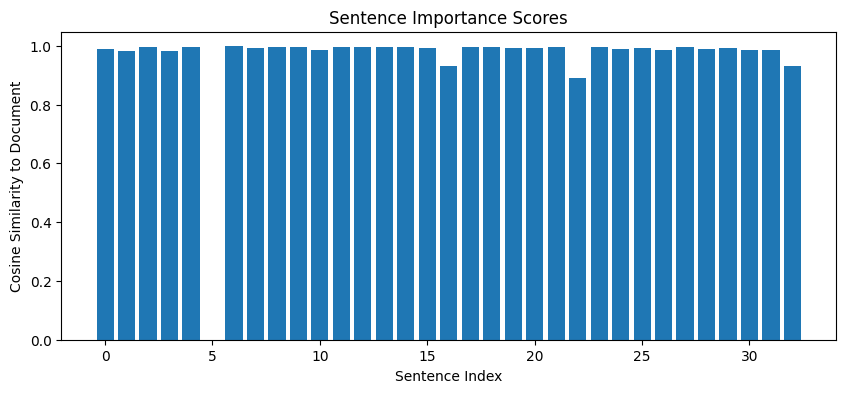

In [30]:
# jsut some extra visualization of the sentence scores for my understanding
#%pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(range(len(scores)), scores)
plt.title("Sentence Importance Scores")
plt.xlabel("Sentence Index")
plt.ylabel("Cosine Similarity to Document")
plt.show()


---
### 4. Abstractive Summarization

Generate a shorter, rephrased summary that captures the key ideas of the extractive

summary while improving fluency and grammatical correctness.
1. Take the top-K sentences obtained from the previous step.
2. Use POS tagging, frequency analysis, or named entity recognition (NER) to identify:

    a. Important nouns (subjects, objects).

    b. Relevant verbs (actions)

    c. Key adjectives/adverbs (descriptors)

3. Combine overlapping or redundant sentences by:

    a. Merging shared subjects/objects.

    b. Removing repeated phrases or low-importance words.

    c. Keeping only top keywords (e.g., using TF-IDF weights).

4. Use POS information or a simple grammar-checking model to refine sentence structure. (Optional).

Expected Abstractive Summary
```
Extractive:
The court found the defendant guilty. The judge dismissed the case.
Abstractive:
The court dismissed the guilty defendant’s case.5. Evaluation
```

In [ ]:
#fixing up some extra dependencies jsut incase ( last one gave me a headache , ain't risking it this time )
%pip install spacy nltk
%python -m spacy download en_core_web_sm

In [34]:
# --> Rule-Based Abstractive Summarizer ( this is what the code below for this part of the assignment is for...)

import spacy
from collections import Counter
import numpy as np
import re

nlp = spacy.load("en_core_web_sm") #loading the small english model - from the ALLOWED BASE LIBRARY 'spacy'

def abstractive_summary(extractive_summary, scores, max_sentence_length = 25):
    # Generating an ever shorter, rephrased summary to capture the key ideas of the extractive summary...

    # 1 - cleaning and tokenizing the extractive summary
    text = re.sub(r'\s+', ' ', extractive_summary).strip()
    doc = nlp(text)
    sentences = list(doc.sents)

    # 2 - Token-analysis , extracting key tokens POS & NER terms
    important_nouns, imp_verbs, imp_adjectives = [], [], []
    for token in doc:
        if token.pos_ == "NOUN" or token.pos_ == "PROPN":
            important_nouns.append(token.lemma_.lower())
        elif token.pos_ == "VERB":
            imp_verbs.append(token.lemma_.lower())
        elif token.pos_ == "ADJ":
            imp_adjectives.append(token.lemma_.lower())
    # named entities like PERSON, ORG, places, etc.
    named_entities = [ ent.text for ent in doc.ents ]

    # 3 - Frequency weighting with scores (using sentence importance)
    word_weights = Counter()
    for i, sentence in enumerate(sentences):
        sentence_score = scores[i] if i < len(scores) else 0
        for token in sentence:
            # use spaCy Token attributes (is_alpha, is_stop) rather than string methods on lemma_
            if token.is_alpha and not token.is_stop:
                word_weights[token.lemma_.lower()] += sentence_score
    top_keywords = [word for word, _ in word_weights.most_common(10)] # top 10 keywords according to weights

    # 4 - Constructing the abstractive summary by merging sentences
    merged_phrases = []
    seen = set() # avoiding duplicates
    for sentence in sentences:
        tokens = [token.lemma_.lower() for token in sentence if token.is_alpha]
        overlap= any(t in seen for t in tokens)
        if not overlap:
            phrase = " ".join( [token.text for token in sentence if token.lemma_.lower() in top_keywords])
            if phrase.strip():
                merged_phrases.append(phrase)
                seen.update(tokens)

    # 5 - Finalizing the summary / Rephrasing compactly
    condensed_summary = []
    for noun in important_nouns[:3]:# taking top 3 nouns
        related_verbs = [v for v in imp_verbs if v not in condensed_summary]
        # pick top verb if available
        verb_part = related_verbs[:1][0] if related_verbs else ''
        phrase = f"{noun} {verb_part}".strip()  # top 1 verbs
        if phrase:
            condensed_summary.append(phrase)
    # combining the merged and condensed phrases
    abstractive_summary_text = ' '.join(merged_phrases + condensed_summary)
    abstractive_summary_text = re.sub(r'\s+', ' ', abstractive_summary_text).strip().capitalize()

    # 6 - limiting to max sentence length
    words = abstractive_summary_text.split()
    if len(words) > max_sentence_length:
        abstractive_summary_text = ' '.join(words[:max_sentence_length]) + '...'

    # 7 - returning the final abstractive summary
    return abstractive_summary_text





In [35]:
# TESTING CODE!!!
# ( moment of truth for the abstractive summarizer everyboddyy)

sentences = [
    "The court found the defendant guilty.",
    "The defendant appealed the decision.",
    "The judge dismissed the case due to insufficient evidence."
]

# Suppose you already have embeddings → these are fake scores just for demo:
scores = np.array([0.9, 0.7, 0.85])
extractive_summary_text = " ".join([sentences[i] for i in [0, 2]])

abstractive = abstractive_summary(extractive_summary_text, scores)
print("Extractive:", extractive_summary_text)
print("Abstractive:", abstractive)


Extractive: The court found the defendant guilty. The judge dismissed the case due to insufficient evidence.
Abstractive: Court found defendant guilty court find defendant find judge find


---
### 5 . COMPLETE NUERAL MODEL RUN ON COMPLETE DATASET

In [ ]:
import os, json, numpy as np
from tqdm import tqdm
from nltk.tokenize import sent_tokenize, word_tokenize

#  Already loaded in notebook:
# vocab, word2idx, W1, W2, pdf_to_text(), clean_text(),
# extractive_summary(), abstractive_summary()

DATA_DIR = "data/judgements/judgementpdfs"
OUTPUT_FILE = "outputs/final_results.json"
OCR_OUTPUT_FILE = "outputs/ocr_data_complete.json"

def get_sentence_embedding(sentence, W1):
    """Average your learned word embeddings for a given sentence."""
    words = [w.lower() for w in word_tokenize(sentence) if w.lower() in word2idx]
    if not words:
        return np.zeros(W1.shape[1])
    vecs = np.array([W1[word2idx[w]] for w in words])
    return np.mean(vecs, axis=0)

results = []
ocr_records = []
pdf_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".pdf")]

for pdf in tqdm(pdf_files, desc="Running NLM pipeline on all legal judgements"):
    pdf_path = os.path.join(DATA_DIR, pdf)
    case_id = os.path.splitext(pdf)[0]

    try:
        #1-OCR + cleaning
        raw_text = pdf_to_text(pdf_path)
        cleaned_text = clean_text(raw_text)

        # save OCR data as well
        ocr_record = {
            "case_id": case_id,
            "pdf_source": pdf_path,
            "ocr_text": cleaned_text
        }
        ocr_records.append(ocr_record)

        #2-Sentence tokenization
        sentences = sent_tokenize(cleaned_text)
        if len(sentences) < 3:
            continue

        #3-Sentence embeddings from your trained model
        sentence_vectors = np.array([get_sentence_embedding(s, W1) for s in sentences])

        #3-Extractive summary
        extractive, scores = extractive_summary(sentences, sentence_vectors, top_k=3)

        #5-Abstractive summary
        abstractive = abstractive_summary(extractive, scores)

        #6-Store final record
        record = {
            "case_id": case_id,
            "pdf_source": pdf_path,
            "num_sentences": len(sentences),
            "extractive_summary": extractive,
            "abstractive_summary": abstractive
        }
        results.append(record)

    except Exception as e:
        print(f"⚠️ Error processing {pdf}: {e}")

#7-Save both OCR data and summarization results
os.makedirs("outputs", exist_ok=True)
with open(OCR_OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(ocr_records, f, indent=4, ensure_ascii=False)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

print(f"\n✅ Completed neural model run on all judgements!")
print(f"📁 OCR text saved to: {OCR_OUTPUT_FILE}")
print(f"📁 Summaries saved to: {OUTPUT_FILE}")



Running NLM pipeline on all legal judgements: 0it [00:00, ?it/s]


✅ Completed neural model run on all judgements!
📁 OCR text saved to: outputs/ocr_dataset.json
📁 Summaries saved to: outputs/final_results.json
